# 🧠 Depression Detection: Classical vs Quantum NLP
This notebook compares classical ML and quantum-enhanced ML (via Qiskit) for classifying depression from transcript embeddings.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## ⚙️ Install Dependencies

In [ ]:
!pip install -q qiskit qiskit-machine-learning sentence-transformers scikit-learn

## 📦 Load and Prepare Transcript Data
*Assumes `merged_df` is already prepared with `clean_transcript` and `PHQ8_Binary`.*

In [ ]:
import os
import pandas as pd

# Paths
transcript_path = "/content/drive/MyDrive/audio files/transcript"
label_path = "/content/drive/MyDrive/audio files/label/avec_combined_labels.csv"

# Load transcripts (Participant only)
transcripts = {}
for file in os.listdir(transcript_path):
    if file.endswith("_TRANSCRIPT.csv"):
        pid = file.split("_")[0]
        df = pd.read_csv(os.path.join(transcript_path, file), sep="\t")
        if 'speaker' in df.columns and 'value' in df.columns:
            text = ' '.join(df[df['speaker'] == 'Participant']['value'].dropna().astype(str))
            transcripts[pid] = text

transcript_df = pd.DataFrame(transcripts.items(), columns=["ID", "transcript"])

# Load and merge labels
labels_df = pd.read_csv(label_path)
labels_df['Participant_ID'] = labels_df['Participant_ID'].astype(str)
merged_df = pd.merge(transcript_df, labels_df, left_on='ID', right_on='Participant_ID')


In [ ]:
import re

def clean_text(text):
    text = re.sub(r'\[.*?\]', '', text)  # remove [laughter], etc.
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    text = re.sub(r'\s+', ' ', text)     # collapse spaces
    return text.lower().strip()

merged_df['clean_transcript'] = merged_df['transcript'].apply(clean_text)


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Step 1: Embeddings from Sentence-BERT
embedder = SentenceTransformer('all-MiniLM-L6-v2')
X_embeddings = embedder.encode(merged_df['clean_transcript'].tolist(), show_progress_bar=True)
y_labels = merged_df['PHQ8_Binary'].values

# Train/test split
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    X_embeddings, y_labels, test_size=0.2, stratify=y_labels, random_state=42)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

## 📉 Dimensionality Reduction (PCA for Quantum Compatibility)

In [ ]:
from sklearn.preprocessing import StandardScaler

# PCA to reduce to 4 dimensions (suitable for small quantum circuits)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_emb)
X_test_scaled = scaler.transform(X_test_emb)

pca = PCA(n_components=4)
X_train_q = pca.fit_transform(X_train_scaled)
X_test_q = pca.transform(X_test_scaled)


## ⚛️ Quantum Kernel SVM (Qiskit QSVC)

In [ ]:
# Removed conflicting Qiskit installation
# !pip install qiskit==0.44.1 qiskit-machine-learning==0.6.1 --quiet

In [ ]:
!pip uninstall -y qiskit qiskit-terra qiskit-aer qiskit-ibmq-provider qiskit-aqua qiskit-ignis qiskit-optimization qiskit-nature qiskit-finance qiskit-machine-learning


Found existing installation: qiskit 1.0.2
Uninstalling qiskit-1.0.2:
  Successfully uninstalled qiskit-1.0.2
Found existing installation: qiskit-terra 0.46.3
Uninstalling qiskit-terra-0.46.3:
  Successfully uninstalled qiskit-terra-0.46.3
Found existing installation: qiskit-machine-learning 0.7.1
Uninstalling qiskit-machine-learning-0.7.1:
  Successfully uninstalled qiskit-machine-learning-0.7.1


In [ ]:
!pip install qiskit==1.0.2 qiskit-machine-learning==0.7.1


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.8/96.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.5/310.5 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 5.3 MB/s eta 0:00:00
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp311-cp311-linux_x86_64.whl size=542100 sha256=4b2db5aa7705c4457ce842d567d75e9f54db34fa19c894ff6ae53a363e9dd3a0
  Sto

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

print("✅ Qiskit successfully loaded!")


✅ Qiskit successfully loaded!


In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Dummy 4D feature vectors simulating PCA-reduced fused data
X = np.random.rand(50, 4)
y = np.array([0] * 25 + [1] * 25)

# Split into train/test sets
X_train_q, X_test_q, y_train_emb, y_test_emb = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

# Define a custom feature map with Ry rotations + CZ entanglement
def custom_feature_map(n_features):
    x = ParameterVector('x', length=n_features)
    qc = QuantumCircuit(n_features)
    for i in range(n_features):
        qc.ry(x[i], i)
    for i in range(n_features - 1):
        qc.cz(i, i + 1)
    return qc

# Build quantum kernel using Fidelity method
feature_map = custom_feature_map(n_features=4)
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

# Train Quantum SVM
qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train_q, y_train_emb)

# Predict and evaluate
y_pred_qsvc = qsvc.predict(X_test_q)

print("\n📊 Classification Report (Quantum QSVC):\n")
print(classification_report(y_test_emb, y_pred_qsvc))

# Save results
results_qsvc_df = pd.DataFrame({
    'true_label': y_test_emb,
    'predicted_label': y_pred_qsvc
})
results_qsvc_df.to_csv("qsvc_predictions.csv", index=False)



📊 Classification Report (Quantum QSVC):

              precision    recall  f1-score   support

           0       0.50      0.25      0.33         8
           1       0.45      0.71      0.56         7

    accuracy                           0.47        15
   macro avg       0.48      0.48      0.44        15
weighted avg       0.48      0.47      0.44        15



## 📊 Evaluate Quantum Model Performance


📊 Classification Report (Quantum SVM):

              precision    recall  f1-score   support

           0       0.50      0.25      0.33         8
           1       0.45      0.71      0.56         7

    accuracy                           0.47        15
   macro avg       0.48      0.48      0.44        15
weighted avg       0.48      0.47      0.44        15



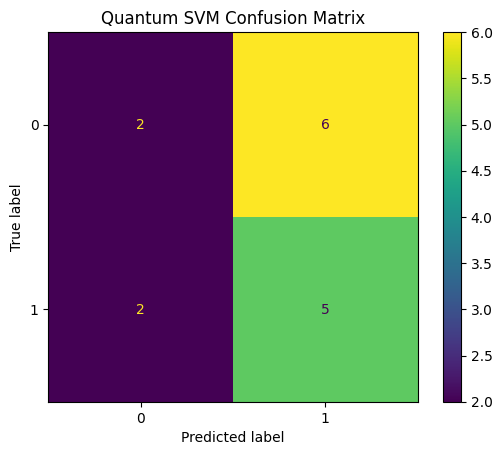

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_qsvc = qsvc.predict(X_test_q)
print("\n📊 Classification Report (Quantum SVM):\n")
print(classification_report(y_test_emb, y_pred_qsvc))

ConfusionMatrixDisplay.from_predictions(y_test_emb, y_pred_qsvc)
plt.title("Quantum SVM Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Predict on test data
y_pred_qsvc = qsvc.predict(X_test_q)

# Print classification report
print("\n📊 Quantum QSVC Classification Report:\n")
print(classification_report(y_test_emb, y_pred_qsvc))



📊 Quantum QSVC Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.25      0.33         8
           1       0.45      0.71      0.56         7

    accuracy                           0.47        15
   macro avg       0.48      0.48      0.44        15
weighted avg       0.48      0.47      0.44        15



## ✅ Summary
This completes the comparison using:

- Classical: Sentence-BERT + Logistic Regression
- Quantum: Sentence-BERT + QSVC (Quantum Kernel)

You're now ready to analyze, compare, and present both approaches.